In [ ]:
import os
current_dir = os.path.basename(os.getcwd())
if not current_dir.startswith('show-and-tell'):
    os.chdir('..')

In [2]:
import torch
import random
import data_utils
import cbm
import numpy as np
import plots
import warnings
warnings.filterwarnings('ignore')

## Load model and data

In [3]:
from demo_utils import get_resnet_imagenet_preprocess

load_dir = "models/imagenet"
device = "cpu"
dataset = "imagenet"
backbone = "resnet50_imagenet"
target_preprocess = get_resnet_imagenet_preprocess()
model = cbm.load_cbm(load_dir, backbone, device)
model.map_size = (14, 14)

In [4]:
val_data = "imagenet_sample_val"
cls_file = data_utils.LABEL_FILES[dataset]

val_data_t = data_utils.get_sample_data(val_data, preprocess=target_preprocess)
val_pil_data = data_utils.get_sample_data(val_data)

In [5]:
with open(cls_file, "r") as f:
    classes = f.read().split("\n")

with open(os.path.join(load_dir, "concepts.txt"), "r") as f:
    concepts = f.read().split("\n")

## Global decision rules

Show classification weights for randomly selected class. 

You can build a Sankey diagram of weights by copying the incoming weights printed below into https://sankeymatic.com/build/

In [6]:
to_show = random.choices([i for i in range(len(classes))], k=1)

for i in to_show:
    print("Output class:{} - {}".format(i, classes[i]))
    print("Incoming weights:")
    for j in range(len(concepts)):
        if torch.abs(model.final.weight[i,j])>0.05:
            print("{} [{:.4f}] {}".format(concepts[j], model.final.weight[i,j], classes[i]))

Output class:249 - Alaskan Malamute
Incoming weights:
a large, fluffy white dog [0.0646] Alaskan Malamute
a smell [0.3063] Alaskan Malamute
a team of huskies [1.1677] Alaskan Malamute
a thick, shaggy coat [0.0738] Alaskan Malamute
black fur with a white mane [0.1001] Alaskan Malamute
bushy tail [0.2657] Alaskan Malamute
red eyes [0.0831] Alaskan Malamute
scent [0.5948] Alaskan Malamute
smooth fur [0.0885] Alaskan Malamute
spotted fur [0.3653] Alaskan Malamute


## Explaining model decisions

Pick a random image and epxlain the model's prediction for it

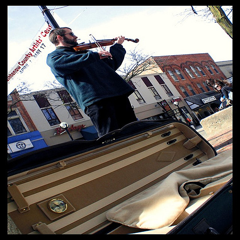

True class: violin, Model pred: violin


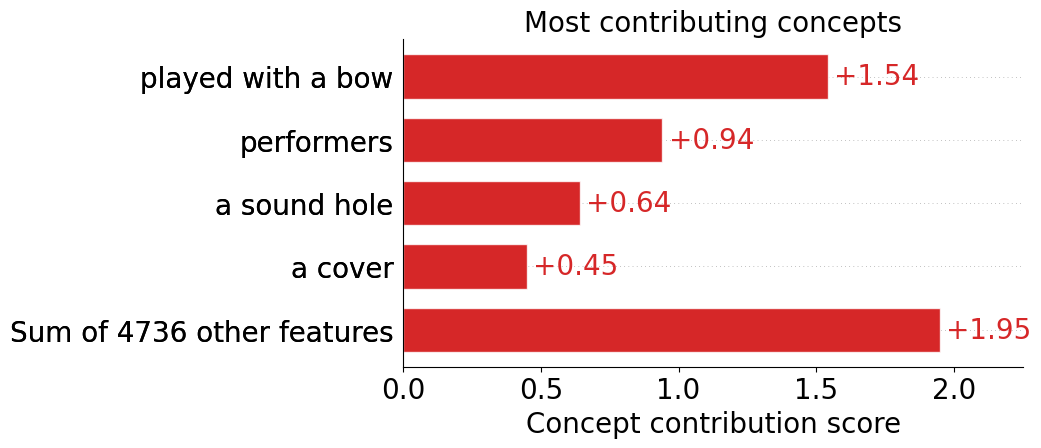

Concept map: played with a bow


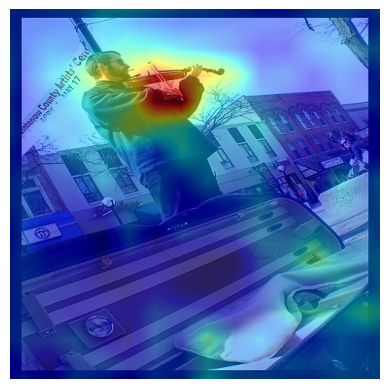

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize
import random

# Select a random image to display
to_display = random.sample(range(len(val_pil_data)), k=1)

for idx in to_display:
    with torch.no_grad():
        # Load image and label
        image, label = val_pil_data[idx]
        input_tensor, _ = val_data_t[idx]
        input_tensor = input_tensor.unsqueeze(0).to(device)

        # Display the image
        display(image.resize((240, 240)))

        # Forward pass
        outputs, concept_activations, concept_maps = model(input_tensor)

        # Print true clasee and predicted class
        top_logit_vals, top_classes = torch.topk(outputs[0], k=2)
        confidences = torch.nn.functional.softmax(outputs[0], dim=0)
        true_class = val_pil_data.classes[int(label)]
        predicted_class = classes[top_classes[0]]
        print(f"True class: {true_class}, Model pred: {predicted_class}")

        # Compute concept contributions scores
        contributions = concept_activations[0] * model.final.weight[top_classes[0]]
        values = contributions.cpu().numpy()

        feature_names = [
            ("NOT " if concept_activations[0][i] < 0 else "") + concepts[i]
            for i in range(len(concepts))
        ]
        max_display = min(np.count_nonzero(np.abs(values) > 0.005) + 1, 5)
        title = (
            f"Pred: {predicted_class} - Conf: {confidences[top_classes[0]]:.3f} - "
            f"Logit: {top_logit_vals[0]:.2f} - Bias: {model.final.bias[top_classes[0]]:.2f}"
        )
        plots.bar(values, feature_names, max_display=max_display, title="Most contributing concepts", fontsize=20)

        # Visualize top contributing concept maps
        top_k_maps = 1
        top_contrib_indices = np.argsort(np.abs(values))[::-1][:top_k_maps]

        for concept_idx in top_contrib_indices:
            fig, ax = plt.subplots()
            ax.imshow(image, extent=(0, 100, 0, 100))
            ax.axis('off')

            # Extract and normalize concept map
            concept_map_vals = concept_maps[0, concept_idx].cpu().numpy()
            normalized_map = concept_map_vals - np.mean(concept_maps[0].cpu().numpy(), axis=0)

            # Resize and overlay heatmap
            heatmap = resize(normalized_map, (224, 224), order=1, mode='reflect', anti_aliasing=True)
            ax.imshow(heatmap, cmap='jet', alpha=0.5, extent=(0, 100, 0, 100))

            print(f"Concept map: {feature_names[concept_idx]}")
            plt.show()
